# Taller ingeniería de datos

El problema que se desea resolver haciendo un modelo predictivo es el siguiente:

*En la industria de telecomunicaciones, la **retención de clientes** es uno de los mayores desafíos para las empresas, ya que la pérdida de clientes (churn) afecta directamente los ingresos y la sostenibilidad del negocio. En este contexto, la empresa que proporciona servicios de telecomunicaciones a través del dataset tiene como objetivo reducir la **tasa de cancelación de sus servicios**. En particular, la variable **Churn Label** identifica a aquellos clientes que han decidido abandonar el servicio. Para abordar este problema, es crucial predecir con antelación qué clientes podrían cancelar su suscripción, para implementar estrategias de retención específicas. Este análisis predictivo no solo ayudaría a identificar a los clientes en riesgo de churn, sino que también podría revelar factores determinantes como la **razón de cancelación**, **tipos de contrato**, **método de pago**, **tasa de uso** y otras variables que influyen en la decisión de los clientes. Por lo tanto, realizar un análisis predictivo basado en estas variables permitirá a la empresa tomar medidas proactivas para mejorar su **estrategia de fidelización** y, en última instancia, reducir el churn y aumentar la **rentabilidad** a largo plazo.*

El equipo de análisis cuenta con un dataset cuyo diccionario de datos se puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

## Carga e identificación de problemas de los datos

Abra el archivo de datos en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargue en `Pandas` el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Indique cuántas variables y registros tiene el dataset, y asegúrese que el tipo de dato de cada variable sea el esperado.

Reporte las estadísticas descriptivas de las variables numéricas y categóricas.

Identifique si el dataframe tiene datos duplicados.

Identifique si hay variables con datos nulos.

Reporte los hallazgos en un celda de texto.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('Telco_customer_churn.csv')

In [3]:
df.head() 

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
f'el dataset tiene {df.shape[0]} registros'

'el dataset tiene 7043 registros'

In [5]:
f'el dataset tiene {df.shape[1]} registros'


'el dataset tiene 33 registros'

In [6]:
df.dtypes

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges            str
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

In [7]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [8]:
df.describe(include='str').T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"33.964131, -118.272783",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [9]:
df.isnull().sum().sort_values(ascending=False).head(5)


Churn Reason    5174
CustomerID         0
Count              0
State              0
Country            0
dtype: int64

In [10]:
df[['Total Charges', 'Churn Reason']].isnull().sum()*100/df.shape[0]


Total Charges     0.000000
Churn Reason     73.463013
dtype: float64

In [11]:
print('Número de registros duplicados: ', df.duplicated().sum())


Número de registros duplicados:  0


In [12]:
df = df.set_index('CustomerID')
df = df.drop(columns=['Count', 'Country', 'State', 'Lat Long'])
df.head()

,City,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
CustomerID,,,,,,,,,,,,,,,,,,,,,
3668-QPYBK,Los Angeles,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
9237-HQITU,Los Angeles,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
9305-CDSKC,Los Angeles,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
7892-POOKP,Los Angeles,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
0280-XJGEX,Los Angeles,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [13]:
df =  df.drop_duplicates()


In [14]:
df = df.drop(columns=['Churn Reason'])
df.info()

<class 'pandas.DataFrame'>
Index: 7043 entries, 3668-QPYBK to 3186-AJIEK
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   str    
 1   Zip Code           7043 non-null   int64  
 2   Latitude           7043 non-null   float64
 3   Longitude          7043 non-null   float64
 4   Gender             7043 non-null   str    
 5   Senior Citizen     7043 non-null   str    
 6   Partner            7043 non-null   str    
 7   Dependents         7043 non-null   str    
 8   Tenure Months      7043 non-null   int64  
 9   Phone Service      7043 non-null   str    
 10  Multiple Lines     7043 non-null   str    
 11  Internet Service   7043 non-null   str    
 12  Online Security    7043 non-null   str    
 13  Online Backup      7043 non-null   str    
 14  Device Protection  7043 non-null   str    
 15  Tech Support       7043 non-null   str    
 16  Streaming TV       7043 n

In [15]:
df.dropna().info()

<class 'pandas.DataFrame'>
Index: 7043 entries, 3668-QPYBK to 3186-AJIEK
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   str    
 1   Zip Code           7043 non-null   int64  
 2   Latitude           7043 non-null   float64
 3   Longitude          7043 non-null   float64
 4   Gender             7043 non-null   str    
 5   Senior Citizen     7043 non-null   str    
 6   Partner            7043 non-null   str    
 7   Dependents         7043 non-null   str    
 8   Tenure Months      7043 non-null   int64  
 9   Phone Service      7043 non-null   str    
 10  Multiple Lines     7043 non-null   str    
 11  Internet Service   7043 non-null   str    
 12  Online Security    7043 non-null   str    
 13  Online Backup      7043 non-null   str    
 14  Device Protection  7043 non-null   str    
 15  Tech Support       7043 non-null   str    
 16  Streaming TV       7043 n

In [16]:
df = df.dropna(subset=['Total Charges'])
df.info()

<class 'pandas.DataFrame'>
Index: 7043 entries, 3668-QPYBK to 3186-AJIEK
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   str    
 1   Zip Code           7043 non-null   int64  
 2   Latitude           7043 non-null   float64
 3   Longitude          7043 non-null   float64
 4   Gender             7043 non-null   str    
 5   Senior Citizen     7043 non-null   str    
 6   Partner            7043 non-null   str    
 7   Dependents         7043 non-null   str    
 8   Tenure Months      7043 non-null   int64  
 9   Phone Service      7043 non-null   str    
 10  Multiple Lines     7043 non-null   str    
 11  Internet Service   7043 non-null   str    
 12  Online Security    7043 non-null   str    
 13  Online Backup      7043 non-null   str    
 14  Device Protection  7043 non-null   str    
 15  Tech Support       7043 non-null   str    
 16  Streaming TV       7043 n

Descarte las variables que considere irrelevantes para su modelo (p.e. claves priamrias, variables con valores únicos, variables redundantes, entre otros).


In [17]:
df = df.drop(columns=["Churn Label", "Churn Score"])

## Análisis de variables categóricas

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

identificar variables categoricas

In [18]:

categorical_cols = df.select_dtypes(include=["str"]).columns.tolist()


variables ordinales

In [19]:
ordinal_cols = ["Contract"]


variables con alta cardinalidad

In [20]:
exclude_cols = ["Churn Label", "Churn Score"]
high_cardinality_cols = [
    col for col in categorical_cols 
    if df[col].nunique() > 5 and col not in exclude_cols
]



variables nominales

In [21]:
nominal_cols = [
    col for col in categorical_cols 
    if col not in ordinal_cols 
    and col not in high_cardinality_cols
    and col not in exclude_cols
]


In [22]:
print("🔹 Variables categóricas totales:")
print(categorical_cols)

print("\n🔹 Variables nominales:")
print(nominal_cols)

print("\n🔹 Variables ordinales:")
print(ordinal_cols)

print("\n🔹 Variables con alta cardinalidad:")
print(high_cardinality_cols)

print("\n🔹 Variables a excluir:")
print(exclude_cols)

🔹 Variables categóricas totales:
['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges']

🔹 Variables nominales:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Paperless Billing', 'Payment Method']

🔹 Variables ordinales:
['Contract']

🔹 Variables con alta cardinalidad:
['City', 'Total Charges']

🔹 Variables a excluir:
['Churn Label', 'Churn Score']


## Análisis de variables cuantitativas

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

In [23]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()


if "Churn Value" in numeric_cols:
    numeric_cols.remove("Churn Value")

print("Variables numéricas analizadas:", numeric_cols)



Variables numéricas analizadas: ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'CLTV']


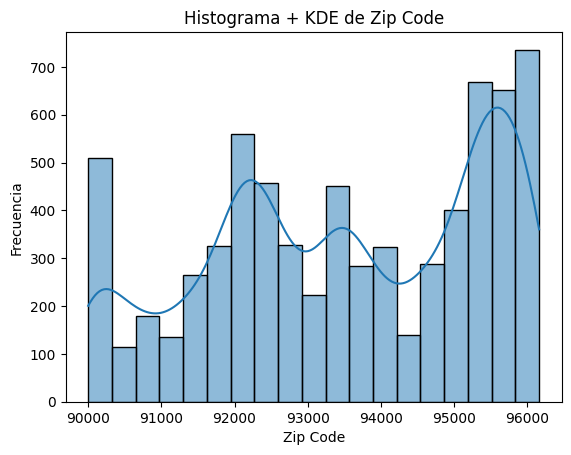

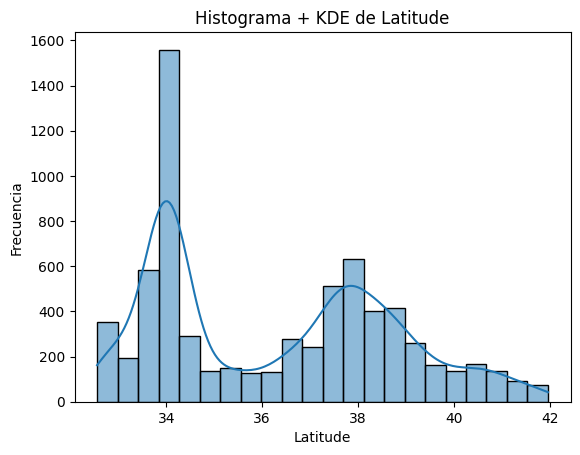

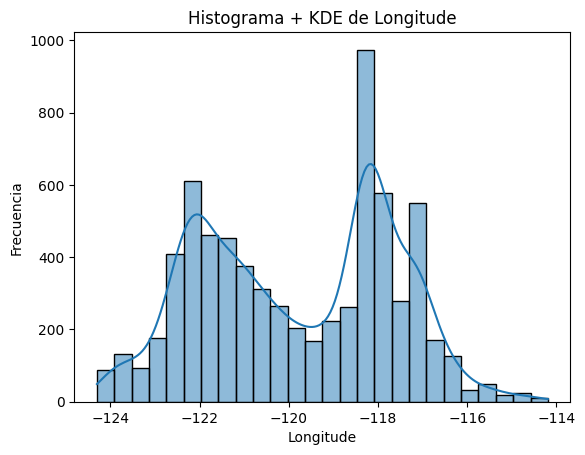

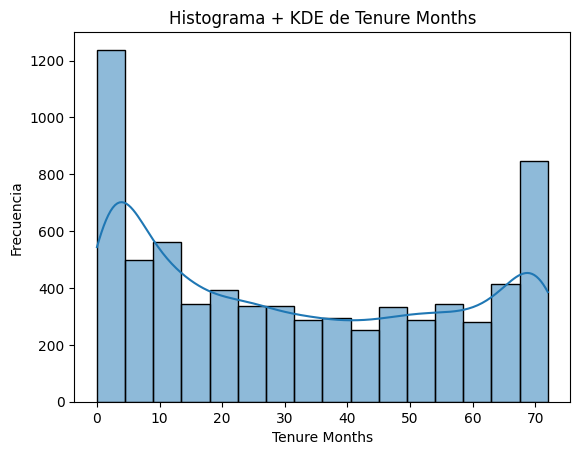

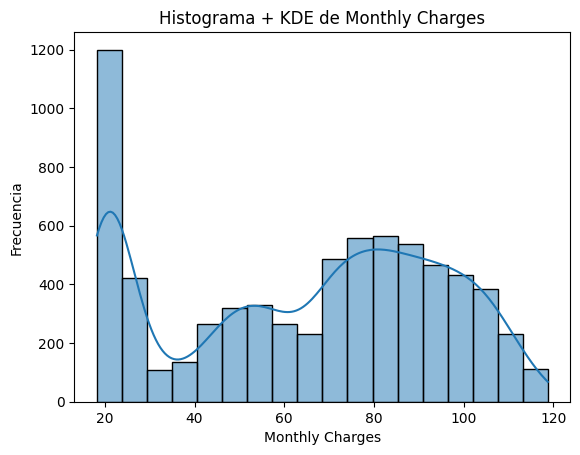

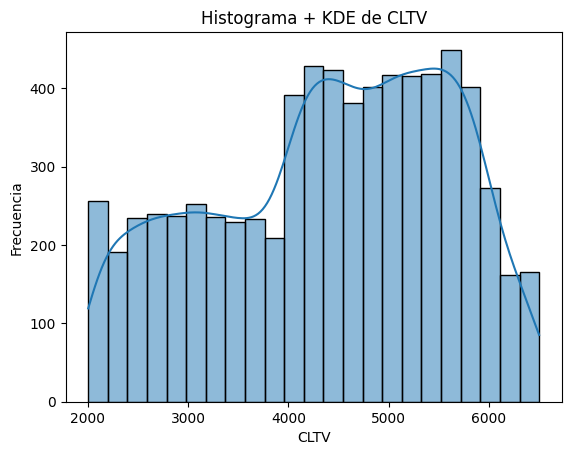

In [24]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Histograma + KDE de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()


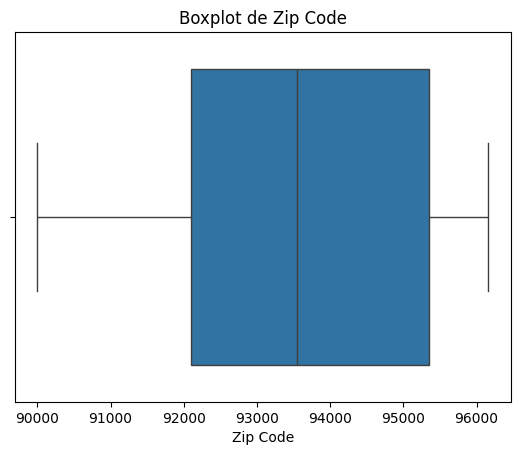

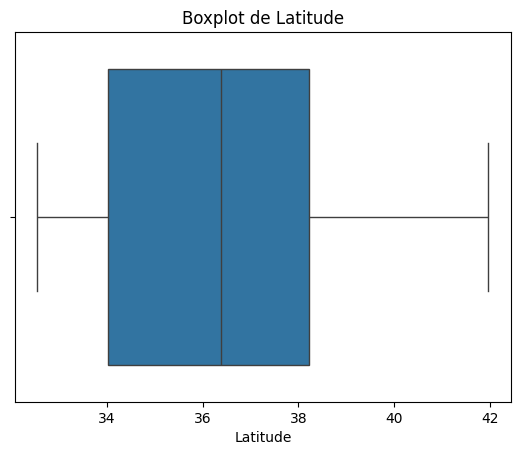

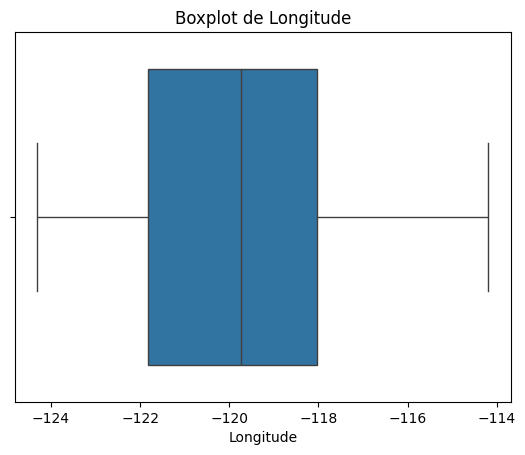

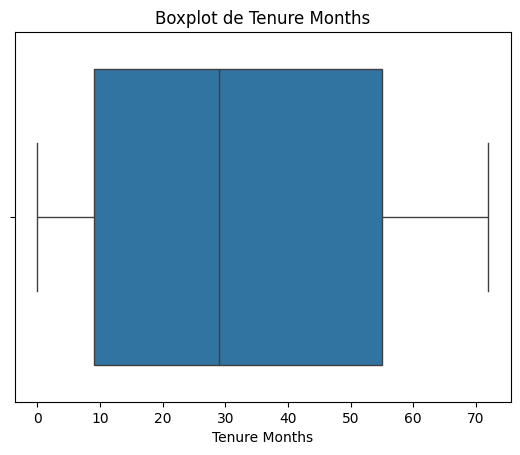

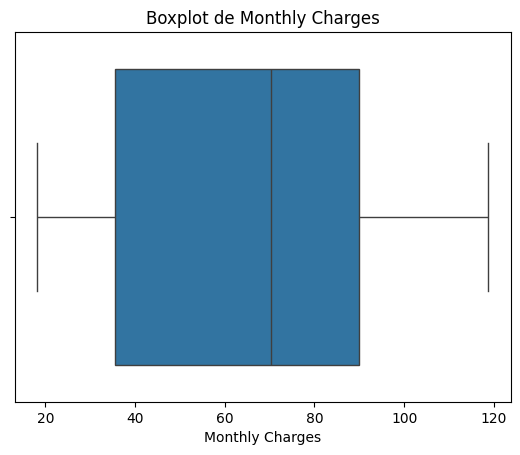

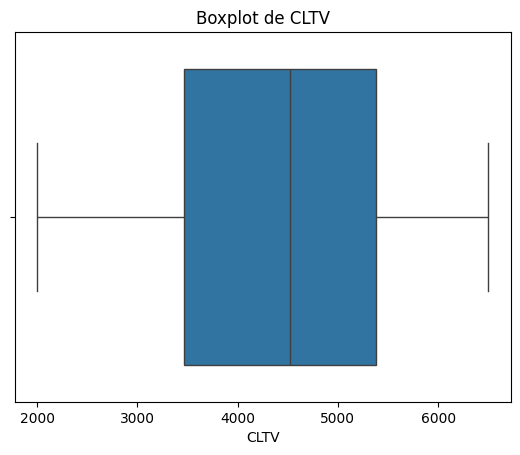

In [25]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

In [26]:
print("\nResumen estadístico:")
print(df[numeric_cols].describe())


Resumen estadístico:
           Zip Code     Latitude    Longitude  Tenure Months  Monthly Charges  \
count   7043.000000  7043.000000  7043.000000    7043.000000      7043.000000   
mean   93521.964646    36.282441  -119.798880      32.371149        64.761692   
std     1865.794555     2.455723     2.157889      24.559481        30.090047   
min    90001.000000    32.555828  -124.301372       0.000000        18.250000   
25%    92102.000000    34.030915  -121.815412       9.000000        35.500000   
50%    93552.000000    36.391777  -119.730885      29.000000        70.350000   
75%    95351.000000    38.224869  -118.043237      55.000000        89.850000   
max    96161.000000    41.962127  -114.192901      72.000000       118.750000   

              CLTV  
count  7043.000000  
mean   4400.295755  
std    1183.057152  
min    2003.000000  
25%    3469.000000  
50%    4527.000000  
75%    5380.500000  
max    6500.000000  


## Entrenamiento del modelo

Entrene un modelo de árbol de decisión que prediga la variable **Churn Value**.

Procese las variables de acuerdo con los análisis de variables cuantitativas y categóricas hechos previamente. Este procesamiento debe empaquetarse usando `ColumnTransformer`, para que los datos de entrenamiento y prueba sean procesados por separado.

Reporte los `scores` de entrenamiento y prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del preprocesamiento.

In [27]:
y = df["Churn Value"]

X = df.drop(columns=[
    "Churn Value",
    "Churn Label",
    "Churn Score",
    "Zip Code",
    "City",
    "Latitude",
    "Longitude",
    "CLTV"
], errors="ignore")

timos de variables

In [28]:
#ordinales
ordinal_cols = ["Contract"]
ordinal_order = [["Month-to-month", "One year", "Two year"]]

# Nominales
nominal_cols = [col for col in X.columns if X[col].dtype == "object" and col not in ordinal_cols]

# Numéricas
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()



In [29]:


preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("ord", OrdinalEncoder(categories=ordinal_order), ordinal_cols),
        ("nom", OneHotEncoder(drop="first", handle_unknown="ignore"), nominal_cols)
    ]
)

In [30]:
# =========================
# 4. Pipeline
# =========================

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])


In [31]:
# =========================
# 5. Train / Test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [32]:
# =========================
# 6. Entrenamiento
# =========================

model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [33]:
# =========================
# 7. Evaluación
# =========================

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_score = accuracy_score(y_train, y_train_pred)
test_score = accuracy_score(y_test, y_test_pred)

print(f"Train score: {train_score:.4f}")
print(f"Test score: {test_score:.4f}")


Train score: 0.9814
Test score: 0.7353


In [34]:
# =========================
# 8. Features reales del modelo
# =========================

# Obtener nombres de columnas transformadas
ohe = model.named_steps["preprocessor"].named_transformers_["nom"]
ohe_features = ohe.get_feature_names_out(nominal_cols)

feature_names = (
    numeric_cols +
    ordinal_cols +
    list(ohe_features)
)

print("\nNúmero total de features después del preprocesamiento:", len(feature_names))
print("\nFeatures finales:")
print(feature_names)

NotFittedError: This OneHotEncoder instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

3. Preprocesamiento

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("ord", OrdinalEncoder(categories=ordinal_order), ordinal_cols),
        ("nom", OneHotEncoder(drop="first", handle_unknown="ignore"), nominal_cols)
    ]
)

pipeline

In [36]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])



Train / Test split

In [37]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


entrenamiento

In [38]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

Evaluación

In [39]:


y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_score = accuracy_score(y_train, y_train_pred)
test_score = accuracy_score(y_test, y_test_pred)

print(f"Train score: {train_score:.4f}")
print(f"Test score: {test_score:.4f}")

Train score: 0.9814
Test score: 0.7353
